# Telecom Customer Churn — Exploratory Data Analysis

## Business Context

A telecommunications company is experiencing **customer churn** — customers cancelling their service and switching to competitors.  
Acquiring a new customer costs **5–25× more** than retaining an existing one (Harvard Business Review).  

**Goal:** Understand *who* is churning and *why*, so we can build a model that identifies at-risk customers before they leave.

**Dataset:** IBM Telco Customer Churn — 7,043 customers, 20 features, binary target (`Churn: Yes/No`)

---
### EDA Roadmap
1. Data overview & quality check  
2. Target distribution  
3. Numeric feature distributions  
4. Churn vs. contract & tenure (key business drivers)  
5. Churn vs. services  
6. Churn vs. charges  
7. Correlation analysis  
8. Key findings summary  

In [1]:
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from src.preprocessing import load_raw

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

CHURN_COLORS = {'No': '#4C9BE8', 'Yes': '#E8604C'}

df = load_raw('../data/raw/telco_churn.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


---
## 1. Data Overview & Quality

In [2]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Missing values:')
print(missing)
print('\nNote: TotalCharges is NaN for customers with tenure=0 (new customers, billed once)')
print(f"Affected rows: {df[df['TotalCharges'].isnull()].shape[0]}")

Missing values:
TotalCharges    11
dtype: int64

Note: TotalCharges is NaN for customers with tenure=0 (new customers, billed once)
Affected rows: 11


In [4]:
# Statistical summary of numeric features
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7032.00
mean,32.37,64.76,2283.30
std,24.56,30.09,2266.77
min,0.00,18.25,18.80
25%,9.00,35.50,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.85,3794.74
max,72.00,118.75,8684.80


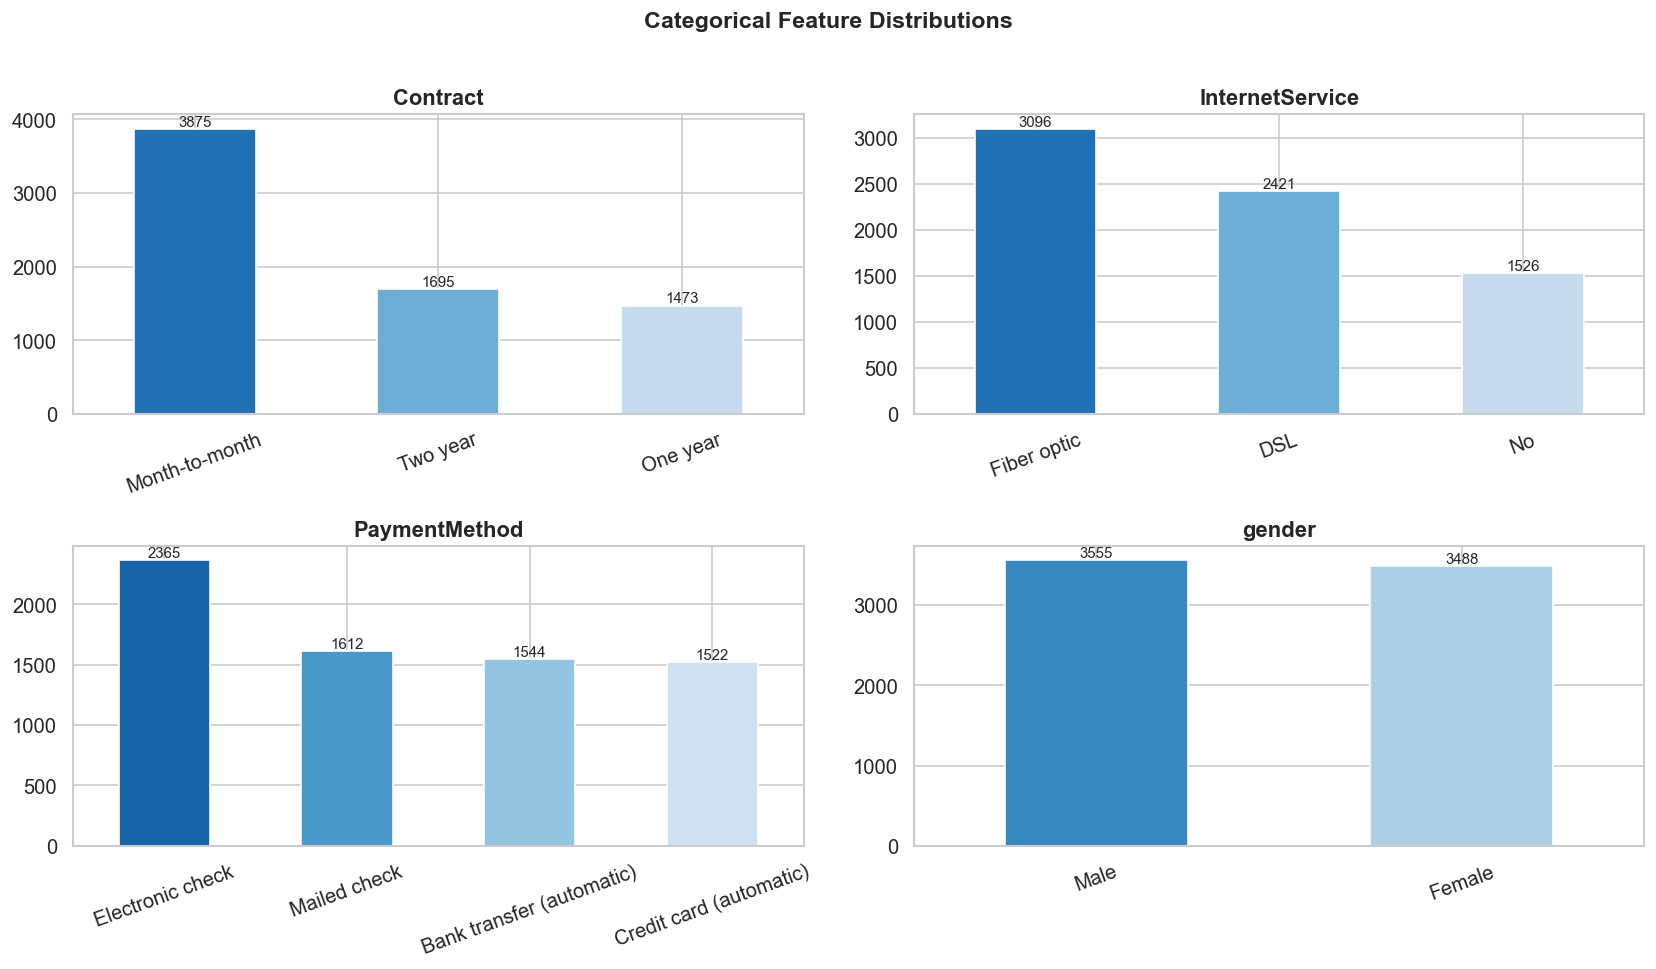

In [5]:
# Value counts for categorical features
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'gender']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    vc = df[col].value_counts()
    vc.plot(kind='bar', ax=ax, color=sns.color_palette('Blues_r', len(vc)), edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/categorical_distributions.png')
plt.show()

---
## 2. Target Distribution

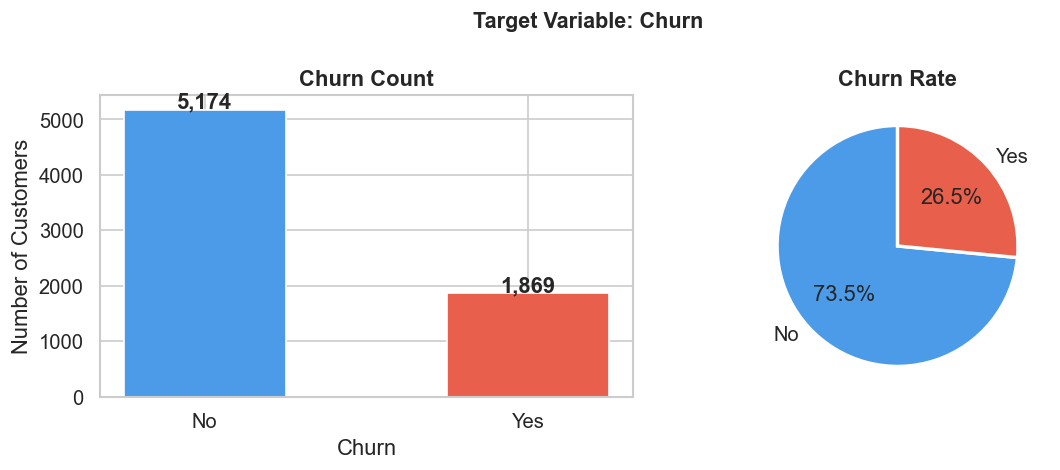

Churn rate: 26.5%  →  Class imbalance ratio 1:2
Action: We will use class_weight=balanced and evaluate on ROC-AUC + F1, not accuracy.


In [6]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
bars = ax1.bar(churn_counts.index, churn_counts.values,
               color=[CHURN_COLORS[k] for k in churn_counts.index], edgecolor='white', width=0.5)
ax1.set_title('Churn Count', fontweight='bold')
ax1.set_xlabel('Churn')
ax1.set_ylabel('Number of Customers')
for bar, val in zip(bars, churn_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}', ha='center', fontweight='bold')

# Pie chart
ax2.pie(churn_counts.values, labels=churn_counts.index,
        autopct='%1.1f%%', colors=[CHURN_COLORS[k] for k in churn_counts.index],
        startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
ax2.set_title('Churn Rate', fontweight='bold')

plt.suptitle('Target Variable: Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/target_distribution.png')
plt.show()

print(f"Churn rate: {churn_pct['Yes']:.1f}%  →  Class imbalance ratio 1:{churn_counts['No']//churn_counts['Yes']}")
print('Action: We will use class_weight=balanced and evaluate on ROC-AUC + F1, not accuracy.')

---
## 3. Numeric Feature Distributions

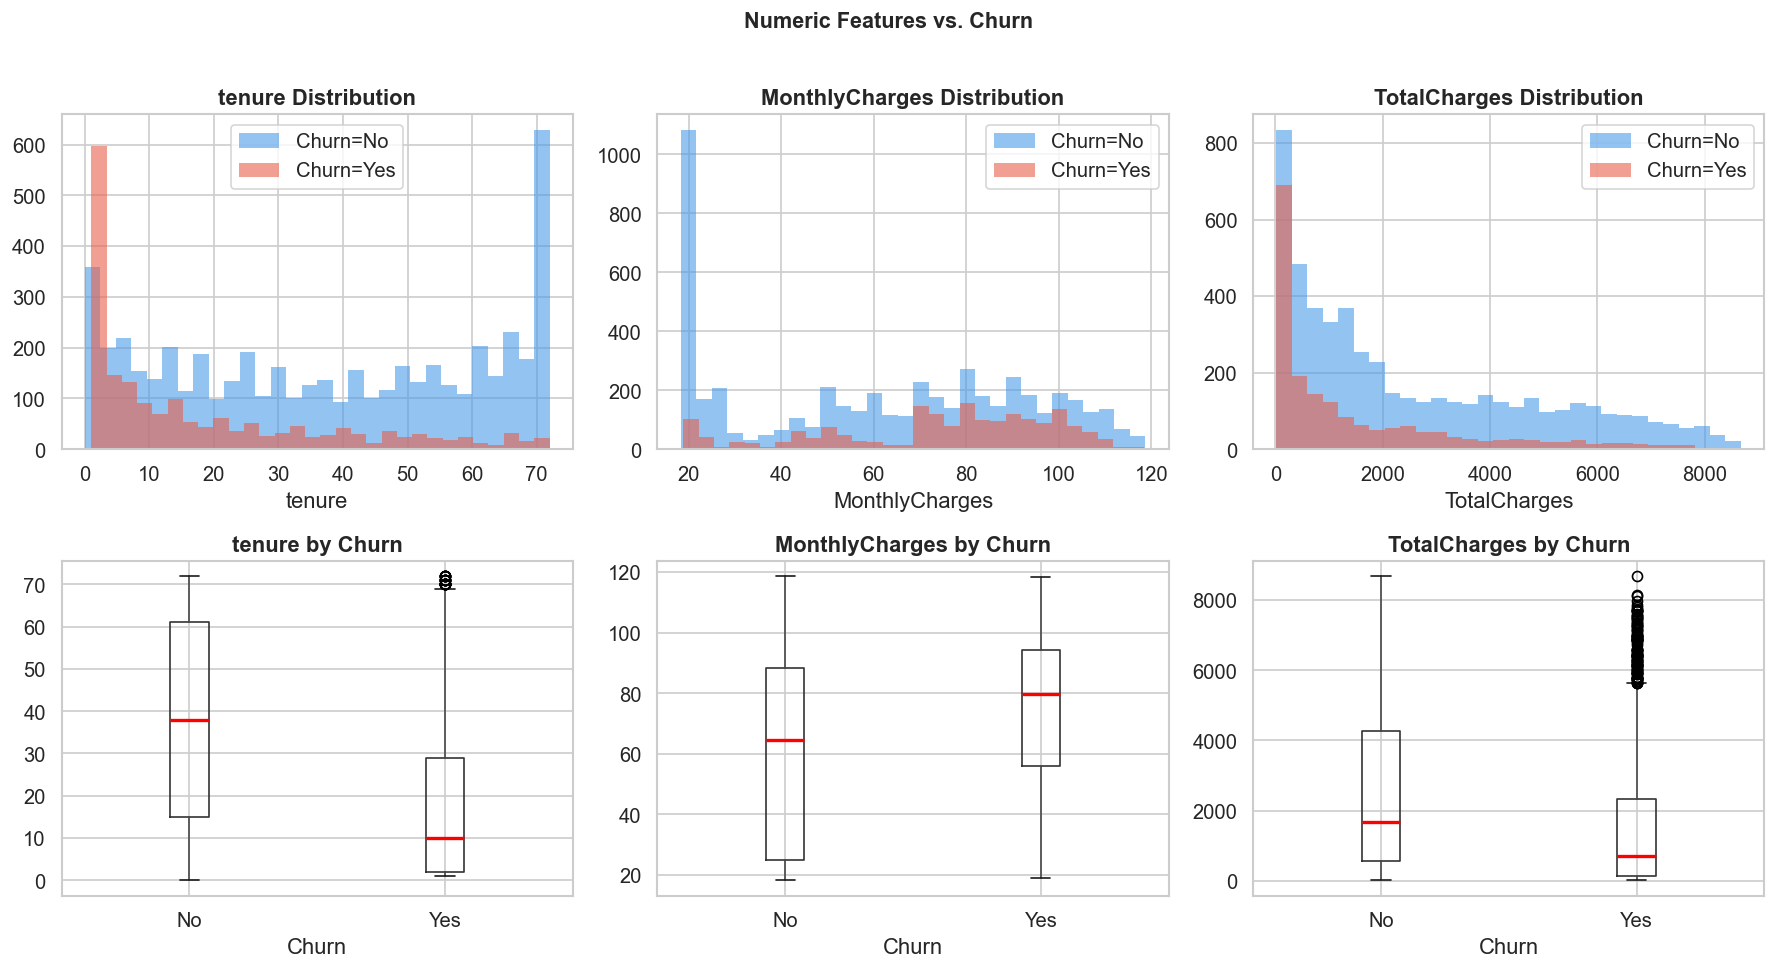

In [7]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(numeric_cols):
    # Distribution by churn
    for churn_val, color in CHURN_COLORS.items():
        subset = df[df['Churn'] == churn_val][col].dropna()
        axes[0, i].hist(subset, bins=30, alpha=0.6, color=color,
                        label=f'Churn={churn_val}', edgecolor='none')
    axes[0, i].set_title(f'{col} Distribution', fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].legend()

    # Box plot by churn
    df.boxplot(column=col, by='Churn', ax=axes[1, i],
               boxprops=dict(color='#333'),
               medianprops=dict(color='red', linewidth=2))
    axes[1, i].set_title(f'{col} by Churn', fontweight='bold')
    axes[1, i].set_xlabel('Churn')

plt.suptitle('Numeric Features vs. Churn', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/numeric_vs_churn.png')
plt.show()

**Observations:**
- **Tenure**: Churners have significantly *shorter* tenure — new customers are most at risk
- **MonthlyCharges**: Churners pay *more* on average — higher bills drive dissatisfaction  
- **TotalCharges**: Lower for churners (consequence of short tenure)

---
## 4. Churn vs. Contract Type & Tenure

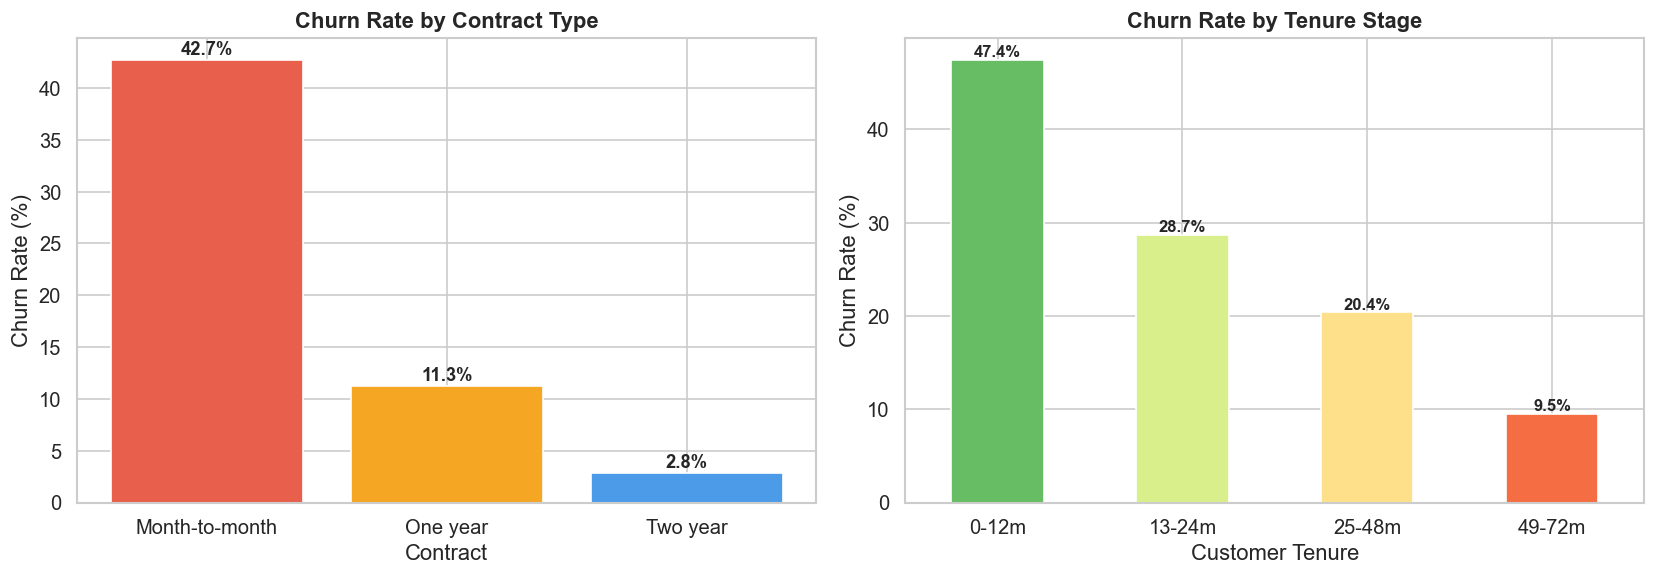

Key insight: Month-to-month customers churn at 3-15x the rate of annual/biennial contract holders.
New customers (0-12 months) are the highest churn risk segment.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate by contract type
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean() * 100)
contract_churn = contract_churn.sort_values(ascending=False)
bars = axes[0].bar(contract_churn.index, contract_churn.values,
                   color=['#E8604C', '#F5A623', '#4C9BE8'], edgecolor='white')
axes[0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('Contract')
for bar, val in zip(bars, contract_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)

# Churn rate by tenure bucket
df['tenure_bucket'] = pd.cut(df['tenure'], bins=[-1, 12, 24, 48, 72],
                              labels=['0-12m', '13-24m', '25-48m', '49-72m'])
tenure_churn = df.groupby('tenure_bucket', observed=True)['Churn'].apply(
    lambda x: (x=='Yes').mean() * 100
)
tenure_churn.plot(kind='bar', ax=axes[1],
                  color=sns.color_palette('RdYlGn_r', 4), edgecolor='white')
axes[1].set_title('Churn Rate by Tenure Stage', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('Customer Tenure')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.3),
                     ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/contract_tenure_churn.png')
plt.show()

print('Key insight: Month-to-month customers churn at 3-15x the rate of annual/biennial contract holders.')
print('New customers (0-12 months) are the highest churn risk segment.')

---
## 5. Churn vs. Internet & Add-on Services

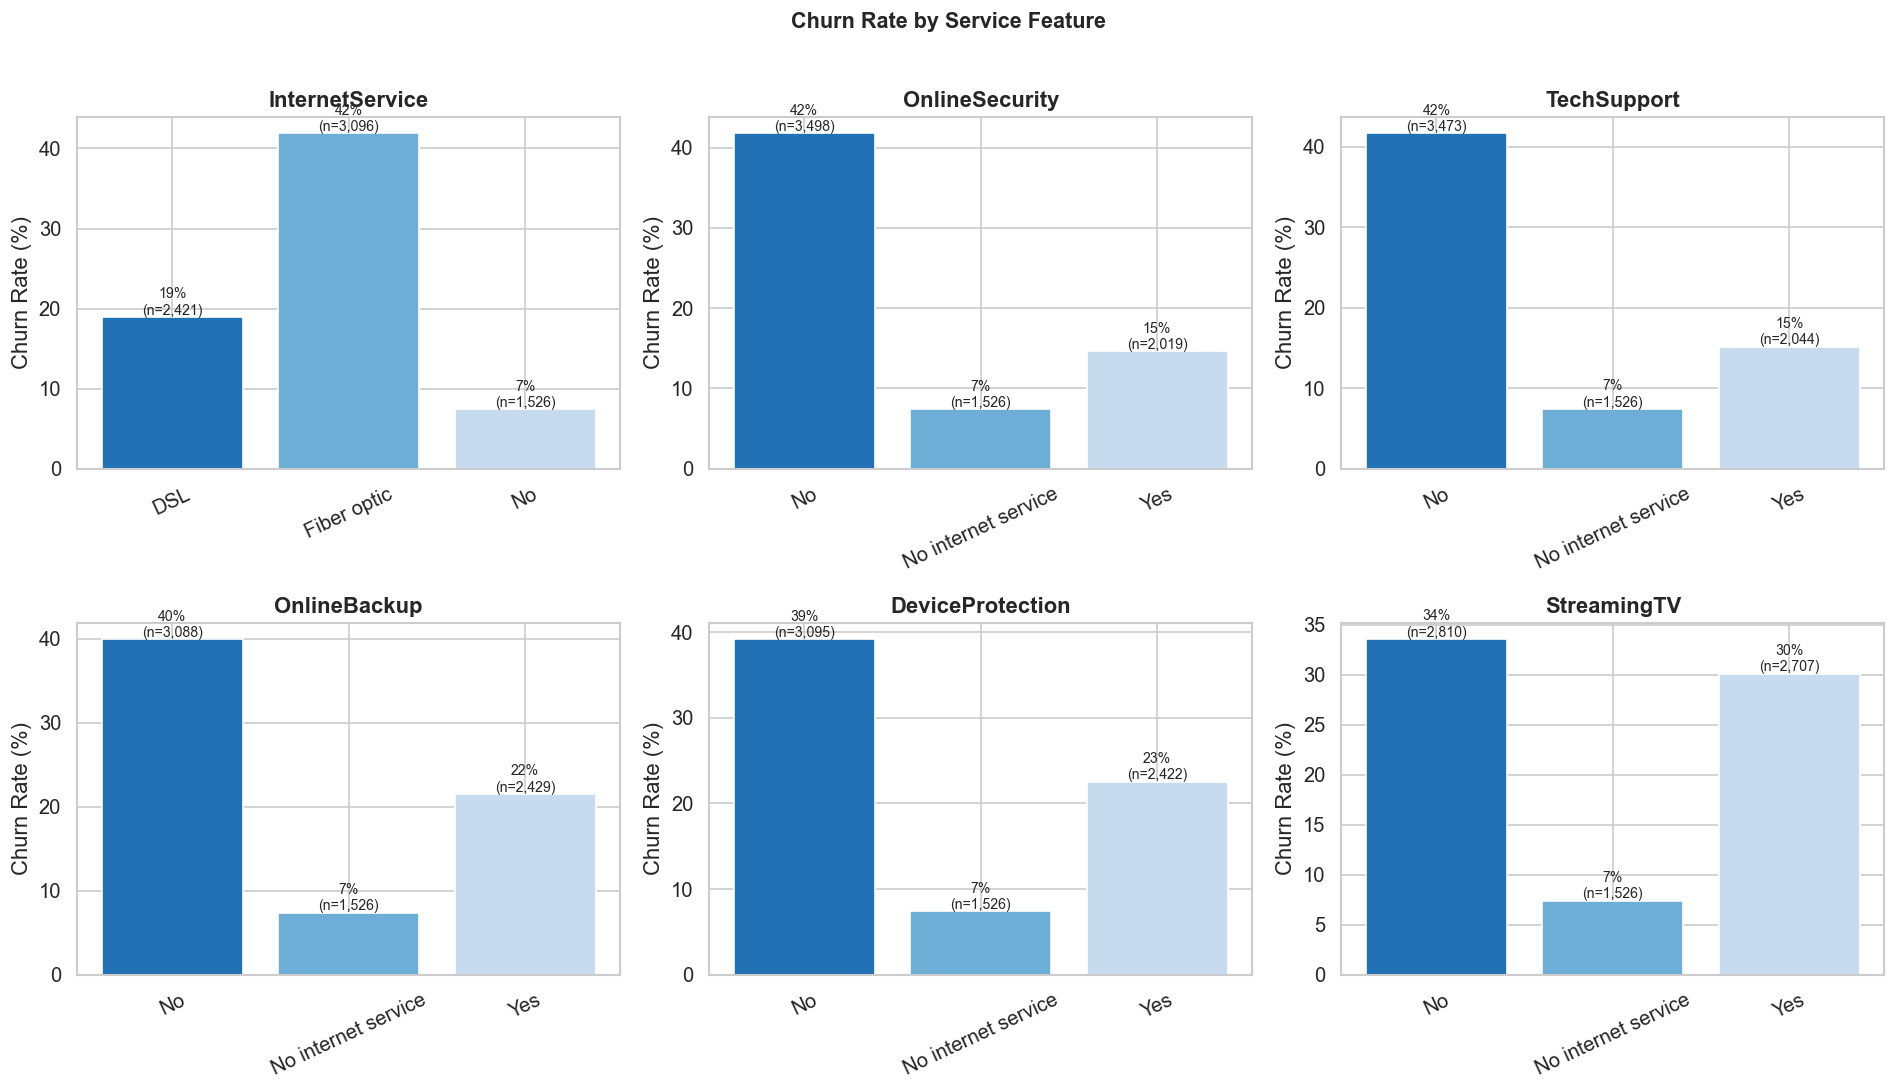

In [9]:
service_cols = [
    'InternetService', 'OnlineSecurity', 'TechSupport',
    'OnlineBackup', 'DeviceProtection', 'StreamingTV',
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), service_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean() * 100)
    n_customers = df[col].value_counts()
    
    colors = sns.color_palette('Blues_r', len(churn_rate))
    bars = ax.bar(churn_rate.index, churn_rate.values, color=colors, edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.tick_params(axis='x', rotation=25)
    
    # Label bars with churn rate + sample size
    for bar, (label, val) in zip(bars, churn_rate.items()):
        n = n_customers.get(label, 0)
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.0f}%\n(n={n:,})', ha='center', fontsize=8.5)

plt.suptitle('Churn Rate by Service Feature', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/services_churn.png')
plt.show()

**Observations:**
- **Fiber optic** customers churn at ~42% — much higher than DSL (~19%)  
  → Likely driven by higher cost; these customers may be price-sensitive
- **OnlineSecurity** and **TechSupport**: Customers *without* these services churn significantly more  
  → These services increase "stickiness" and perceived value

---
## 6. Churn vs. Monthly Charges

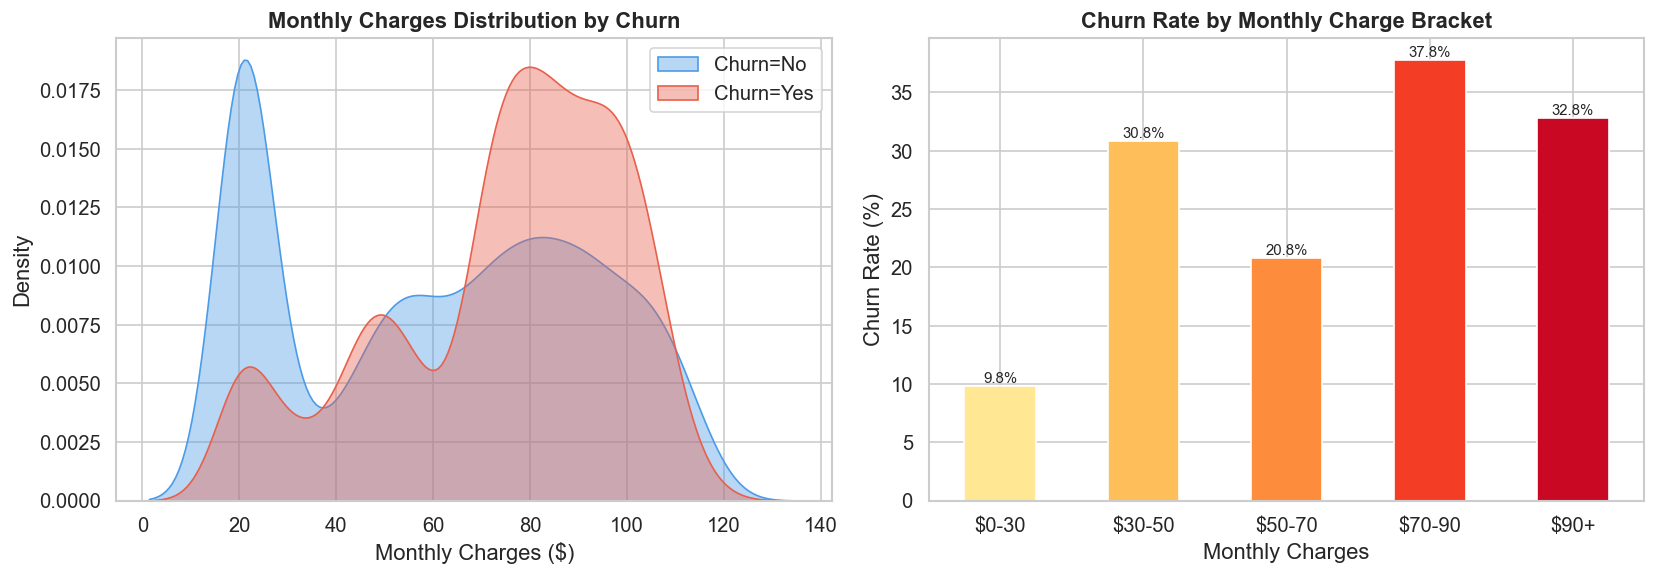

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE plot — MonthlyCharges distribution by churn
for churn_val, color in CHURN_COLORS.items():
    subset = df[df['Churn'] == churn_val]['MonthlyCharges']
    sns.kdeplot(subset, ax=axes[0], color=color, fill=True, alpha=0.4, label=f'Churn={churn_val}')
axes[0].set_title('Monthly Charges Distribution by Churn', fontweight='bold')
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].legend()

# Churn rate by charge bracket
df['charge_bracket'] = pd.cut(df['MonthlyCharges'],
                               bins=[0, 30, 50, 70, 90, 120],
                               labels=['$0-30', '$30-50', '$50-70', '$70-90', '$90+'])
bracket_churn = df.groupby('charge_bracket', observed=True)['Churn'].apply(
    lambda x: (x=='Yes').mean() * 100
)
bracket_churn.plot(kind='bar', ax=axes[1],
                   color=sns.color_palette('YlOrRd', 5), edgecolor='white')
axes[1].set_title('Churn Rate by Monthly Charge Bracket', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('Monthly Charges')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.3),
                     ha='center', fontsize=9)

# Drop temp column
df.drop(columns=['charge_bracket'], inplace=True)

plt.tight_layout()
plt.savefig('../reports/figures/charges_churn.png')
plt.show()

---
## 7. Correlation Analysis

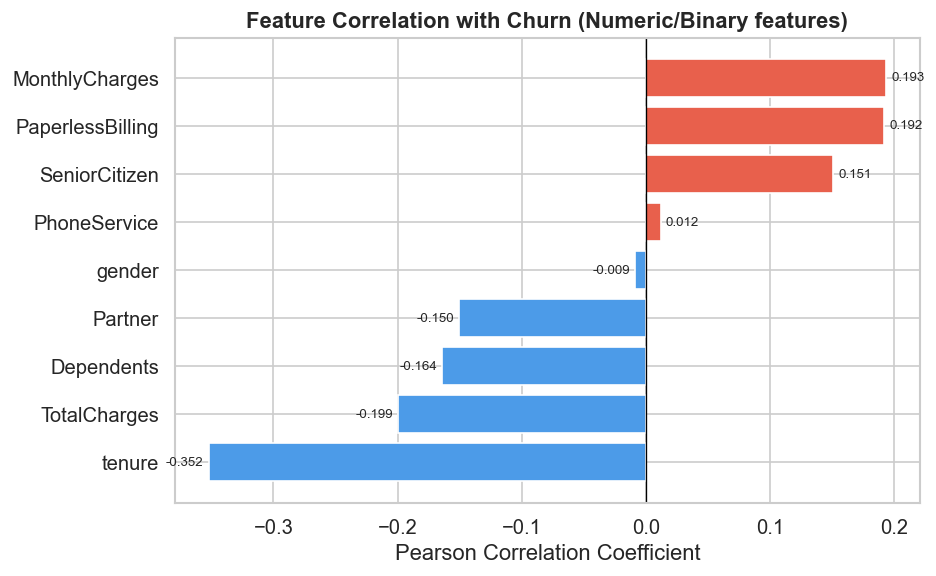

In [11]:
# Encode for correlation
df_enc = df.copy()
df_enc['Churn_bin'] = (df_enc['Churn'] == 'Yes').astype(int)

binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for col in ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']:
    df_enc[col] = df_enc[col].map(binary_map)

# Point-biserial correlations with churn
numeric_for_corr = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
                    'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
corr_with_churn = df_enc[numeric_for_corr + ['Churn_bin']].corr()['Churn_bin'].drop('Churn_bin').sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#E8604C' if v > 0 else '#4C9BE8' for v in corr_with_churn.values]
bars = ax.barh(corr_with_churn.index, corr_with_churn.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Churn (Numeric/Binary features)', fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
plt.tight_layout()
plt.savefig('../reports/figures/correlation_with_churn.png')
plt.show()

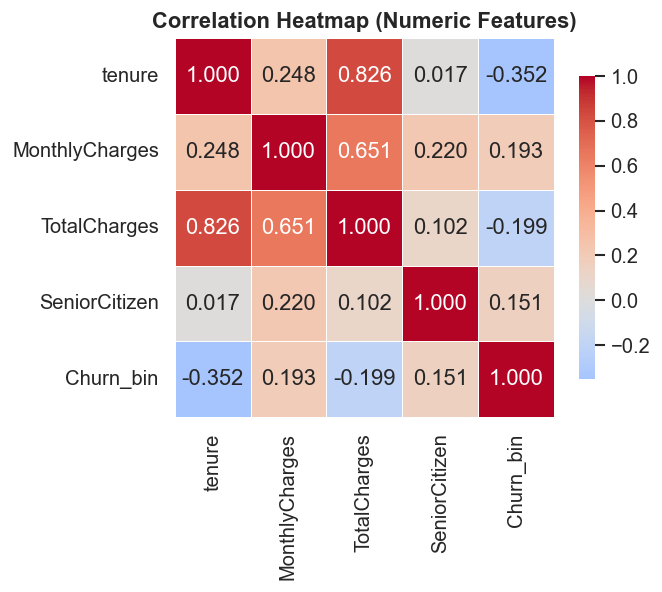

Note: TotalCharges is highly correlated with tenure (r=0.83) — expected, since TotalCharges ≈ tenure × MonthlyCharges.
We will address this multicollinearity in feature engineering.


In [12]:
# Heatmap — numeric features only
corr_matrix = df_enc[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_bin']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            ax=ax, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap (Numeric Features)', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png')
plt.show()

print('Note: TotalCharges is highly correlated with tenure (r=0.83) — expected, since TotalCharges ≈ tenure × MonthlyCharges.')
print('We will address this multicollinearity in feature engineering.')

---
## 8. Summary of Key Findings

| Finding | Implication for Model |
|---------|----------------------|
| **Month-to-month contracts** → ~43% churn rate | `Contract` will be the most predictive feature |
| **Short tenure (0-12 months)** → >40% churn rate | `tenure` is a strong negative predictor |
| **Fiber optic internet** → ~42% vs. DSL ~19% | `InternetService` encodes price sensitivity |
| **No OnlineSecurity / TechSupport** → higher churn | Add-on services increase retention |
| **Higher MonthlyCharges** → higher churn | Charge sensitivity, especially Fiber customers |
| **Electronic check payment** → highest churn | Correlated with month-to-month contracts |
| **TotalCharges ↔ tenure** (r=0.83) | Multicollinearity — feature engineer to reduce |
| **Class imbalance** (26.5% Yes) | Use `class_weight='balanced'`, evaluate ROC-AUC & F1 |

---
**Next:** `02_modeling.ipynb` — feature engineering, model training, SHAP explainability, business impact